### FASE 0 — Preparación 
Esta fase inicial configura el entorno de trabajo, importa las librerías base pandas, numpy, matplotlib y define funciones de utilidad para estandarizar textos y nombres de columnas.

In [1]:
import sys, numpy as np, pandas as pd, matplotlib.pyplot as plt
from pathlib import Path

np.random.seed(42)
pd.set_option("display.max_columns", 200)

def std_name(c):
    return (str(c).strip().replace("\n"," ").replace("\r"," ")
            .lower().replace(" ","_")
            .replace("á","a").replace("é","e").replace("í","i")
            .replace("ó","o").replace("ú","u").replace("ñ","n"))

def normaliza_txt(x):
    s = str(x).strip().upper()
    for a,b in (("Á","A"),("É","E"),("Í","I"),("Ó","O"),("Ú","U"),("Ü","U"),("Ñ","N")):
        s = s.replace(a,b)
    return s

ON_WEB = (sys.platform == "emscripten")  # JupyterLite/Pyodide
print("Entorno:", "Web (sin pip)" if ON_WEB else sys.platform)

Entorno: win32


### FASE 1 — Selección y normalización 
En esta fase se lee el conjunto de datos desde el archivo CSV, se detecta de manera inteligente la fila de los encabezados, se normalizan dichos encabezados y se aplica un saneamiento a las variables numéricas reemplazando caracteres no válidos e imputando nulos con 0.

In [2]:
import numpy as np, pandas as pd
from pathlib import Path

# 1) Ruta del CSV
RUTA_CSV = "ant_datos_licencias_2022_mayo_hoja.csv"
assert Path(RUTA_CSV).exists(), f"No se encontró {RUTA_CSV}. Sube el CSV correcto."

# 2) Leer todo como texto, con separador ';'
raw = pd.read_csv(RUTA_CSV, sep=";", header=None, dtype=str, engine="python", encoding="utf-8")

# 3) Detectar automáticamente la fila que contiene los encabezados reales
TOKENS = {"A","A1","B","C","C1","D","E","F","G","TOTAL GENERAL","TOTAL_GENERAL","TOTALGENERAL"}

def score_header_row(row):
    vals = [str(x).strip().upper() for x in row.tolist()]
    hits = sum(v in TOKENS for v in vals)
    nstr = sum(v != "" for v in vals)
    return hits*1000 + nstr

hdr_idx = raw.apply(score_header_row, axis=1).idxmax()
header_vals = [str(x).strip() for x in raw.iloc[hdr_idx].tolist()]

if header_vals and (header_vals[0] == "" or header_vals[0].lower().startswith("unnamed")):
    header_vals[0] = "unidad"

cols_std = [std_name(c) for c in header_vals]

# 4) Construir df_crudo con ese encabezado
df_crudo = raw.iloc[hdr_idx+1:].copy()
df_crudo.columns = cols_std

df_crudo = df_crudo.apply(lambda s: s.map(lambda x: str(x).strip() if pd.notna(x) else x) if s.dtype == "object" else s)

if df_crudo.columns[0] != "unidad":
    df_crudo = df_crudo.rename(columns={df_crudo.columns[0]: "unidad"})

cols_esperadas = ["unidad","a","a1","b","c","c1","d","e","f","g","total_general"]
df_crudo = df_crudo.loc[:, df_crudo.notna().any(axis=0)]
df_crudo = df_crudo[[c for c in cols_esperadas if c in df_crudo.columns]]

# 5) Limpieza numérica segura
clases_cols = [c for c in ["a","a1","b","c","c1","d","e","f","g"] if c in df_crudo.columns]
num_cols    = clases_cols + (["total_general"] if "total_general" in df_crudo.columns else [])
df_crudo = df_crudo.replace({"-": np.nan, "—": np.nan, "–": np.nan})

for c in num_cols:
    df_crudo[c] = (df_crudo[c].astype(str)
                   .str.replace(r"[^\d,.\-]", "", regex=True)
                   .str.replace(".", "", regex=False)
                   .str.replace(",", ".", regex=False))
    df_crudo[c] = pd.to_numeric(df_crudo[c], errors="coerce")

# 6) Saneamiento: clases NaN → 0 y total_general consistente
if clases_cols:
    df_crudo[clases_cols] = df_crudo[clases_cols].fillna(0)
    suma_clases = df_crudo[clases_cols].sum(axis=1)
    if "total_general" in df_crudo.columns:
        df_crudo["total_general"] = df_crudo["total_general"].fillna(suma_clases)
        dif = (df_crudo["total_general"] - suma_clases).abs()
        df_crudo.loc[dif > 0.5, "total_general"] = suma_clases
    else:
        df_crudo["total_general"] = suma_clases

    df_crudo[clases_cols + ["total_general"]] = df_crudo[clases_cols + ["total_general"]].astype(int, errors="ignore")

# 7) Salida de control
print(f"FASE 1 OK → filas: {df_crudo.shape[0]} | columnas: {df_crudo.shape[1]}")
print("Columnas:", list(df_crudo.columns))
display(df_crudo.head())


FASE 1 OK → filas: 504 | columnas: 11
Columnas: ['unidad', 'a', 'a1', 'b', 'c', 'c1', 'd', 'e', 'f', 'g', 'total_general']


,unidad,a,a1,b,c,c1,d,e,f,g,total_general
2,AZUAY,99,0,993,460,0,32,315,27,30,1956
3,Enero,20,0,133,86,0,10,25,3,13,290
4,Duplicado o Reimpresión de Licencia,6,0,75,22,0,8,21,1,1,134
5,Emisión de Licencia por Primera Vez,1,0,41,63,0,0,1,0,12,118
6,Renovación de Licencia,13,0,17,1,0,2,3,2,0,38


### FASE 2 — Extraer provincias (24) 
Esta etapa se encarga de aislar y consolidar únicamente los registros que corresponden a las 24 provincias del país, eliminando filas que representen subtotales por meses u otros tipos de agrupación que ensucian el análisis geográfico.

In [3]:
assert 'df_crudo' in globals(), "Primero ejecuta la Fase 1 (df_crudo)."

MESES = {"ENERO","FEBRERO","MARZO","ABRIL","MAYO","JUNIO","JULIO","AGOSTO","SEPTIEMBRE","OCTUBRE","NOVIEMBRE","DICIEMBRE"}
PALABRAS_TIPO = ["DUPLICADO","REIMPRES","RECATEG","PRIMERA VEZ","RENOVAC","EMISION"]

PROVINCIAS = {
    "AZUAY","BOLIVAR","CANAR","CARCHI","COTOPAXI","CHIMBORAZO","EL ORO","ESMERALDAS","GUAYAS",
    "IMBABURA","LOJA","LOS RIOS","MANABI","MORONA SANTIAGO","NAPO","PASTAZA","PICHINCHA",
    "SANTA ELENA","SANTO DOMINGO DE LOS TSACHILAS","SUCUMBIOS","TUNGURAHUA","ZAMORA CHINCHIPE",
    "GALAPAGOS","ORELLANA"
}

dfN = df_crudo.copy()
dfN["unidad_norm"] = dfN["unidad"].map(normaliza_txt)
dfN["_n_num"] = dfN[clases_cols].notna().sum(axis=1)

mask_cat  = dfN["unidad_norm"].isin(PROVINCIAS)
mask_mes  = dfN["unidad_norm"].isin(MESES)
mask_tipo = False
for k in PALABRAS_TIPO:
    mask_tipo = mask_tipo | dfN["unidad_norm"].str.contains(k, na=False)

mask_heur = (
    ~mask_mes & ~mask_tipo &
    dfN["unidad_norm"].str.match(r"^[A-Z\s\.]+$", na=False) &
    (dfN["unidad_norm"].str.len() <= 30) &
    (dfN["_n_num"] >= 3)
)

mask_prov = mask_cat | mask_heur
df_prov   = dfN.loc[mask_prov, ["unidad"] + clases_cols].copy()

if "total_general" in df_prov.columns:
    df_prov["_tg"] = df_prov["total_general"].fillna(0)
    df_prov = (df_prov
               .assign(unidad_norm=df_prov["unidad"].map(normaliza_txt))
               .sort_values(["unidad_norm","_tg"], ascending=[True,False])
               .drop_duplicates("unidad_norm", keep="first")
               .drop(columns=["unidad_norm","_tg"])
               .reset_index(drop=True))
else:
    df_prov = (df_prov
               .assign(unidad_norm=df_prov["unidad"].map(normaliza_txt))
               .drop_duplicates("unidad_norm", keep="first")
               .drop(columns=["unidad_norm"])
               .reset_index(drop=True))

prov_detectadas = sorted(df_prov["unidad"].map(normaliza_txt).unique().tolist())
faltantes = sorted(list(PROVINCIAS - set(prov_detectadas)))

print(f"Provincias detectadas: {len(prov_detectadas)}")
if faltantes:
    print("\nFaltantes (según catálogo):", faltantes)

df_prov = df_prov.sort_values("unidad").reset_index(drop=True)
display(df_prov.head())


Provincias detectadas: 25


,unidad,a,a1,b,c,c1,d,e,f,g
0,AZUAY,99,0,993,460,0,32,315,27,30
1,BOLIVAR,173,0,1317,666,0,175,669,2,43
2,CARCHI,25,0,332,129,0,48,196,0,2
3,CAÑAR,137,2,1756,340,0,115,468,6,14
4,CHIMBORAZO,60,0,976,439,3,121,362,8,16


### FASE 3 — Transformación Explicación 
Aquí se transforma el conjunto de datos para el cálculo de proporciones de emisión por tipo de licencia dentro de cada provincia creando las variables prop_*, lo cual es fundamental para alimentar los modelos predictivos posteriores.

In [4]:
assert 'df_prov' in globals(), "Antes debe ejecutarse la Fase 2."

clases_presentes = [c for c in ["a","a1","b","c","c1","d","e","f","g"] if c in df_prov.columns]
assert len(clases_presentes) > 0, "No se encontraron columnas de clases."

dfp = df_prov.copy()
dfp[clases_presentes] = dfp[clases_presentes].fillna(0)

prov_long = dfp.melt(id_vars=["unidad"], value_vars=clases_presentes, var_name="clase", value_name="emisiones")
prov_long["emisiones"] = pd.to_numeric(prov_long["emisiones"], errors="coerce").fillna(0).astype(int)

tot_calc = prov_long.groupby("unidad", as_index=False)["emisiones"].sum().rename(columns={"emisiones":"total_calc"})

df_prov2 = dfp.merge(tot_calc, on="unidad", how="left")
if "total_general" in df_prov2.columns:
    dif = (df_prov2["total_general"].fillna(0) - df_prov2["total_calc"].fillna(0)).abs()
    df_prov2["_total"] = np.where(dif > 0.5, df_prov2["total_calc"], df_prov2["total_general"])
else:
    df_prov2["_total"] = df_prov2["total_calc"]

suma_clases = df_prov2[clases_presentes].sum(axis=1)
suma_clases = suma_clases.replace(0, np.nan)
for c in clases_presentes:
    df_prov2[f"prop_{c}"] = (df_prov2[c] / suma_clases).round(6)

df_prov2 = df_prov2.sort_values("_total", ascending=False).reset_index(drop=True)
cols_mostrar = ["unidad","_total"] + clases_presentes + [f"prop_{c}" for c in clases_presentes]

display(df_prov2[cols_mostrar].head())


,unidad,_total,a,a1,b,c,c1,d,e,f,g,prop_a,prop_a1,prop_b,prop_c,prop_c1,prop_d,prop_e,prop_f,prop_g
0,Total general,118000,11348,221,65958,12833,86,4616,21216,487,1235,0.096169,0.001873,0.558966,0.108754,0.000729,0.039119,0.179797,0.004127,0.010466
1,GUAYAS,26631,1265,13,18756,1496,31,636,4041,75,318,0.047501,0.000488,0.704292,0.056175,0.001164,0.023882,0.151740,0.002816,0.011941
2,MANABÍ,26546,3607,171,14749,2202,15,1046,4487,89,180,0.135877,0.006442,0.555602,0.082950,0.000565,0.039403,0.169027,0.003353,0.006781
3,LOS RÍOS,10525,1146,14,5958,922,3,427,1942,44,69,0.108884,0.001330,0.566081,0.087601,0.000285,0.040570,0.184513,0.004181,0.006556
4,PICHINCHA,8139,467,0,5199,686,21,253,1396,100,17,0.057378,0.000000,0.638776,0.084286,0.002580,0.031085,0.171520,0.012287,0.002089


### FASE 4 — Clasificación Top vs. no-Top (autosuficiente)
 En la fase de minería de datos, se entrena un modelo Random Forest para clasificar si una provincia pertenece al segmento Top de emisiones basándose en las proporciones la mezcla de tipos de licencia, evaluando el modelo con métricas de clasificación y determinando la importancia de las variables.

In [5]:
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report, make_scorer
from sklearn.ensemble import RandomForestClassifier

assert 'df_prov2' in globals(), "Ejecuta primero la Fase 3."

mix_cols = [c for c in df_prov2.columns if c.startswith("prop_")]

# Etiqueta Top (Q3)
score = df_prov2["_total"]
q3 = score.quantile(0.75)
y = (score >= q3).astype(int)

min_pos = max(3, int(np.ceil(len(df_prov2) * 0.25)))
if y.sum() < min_pos:
    idx_top = score.sort_values(ascending=False).head(min_pos).index
    y = pd.Series(0, index=score.index); y.loc[idx_top] = 1

X = df_prov2[mix_cols].fillna(0)
Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.30, random_state=42, stratify=y)

clf = RandomForestClassifier(n_estimators=600, class_weight="balanced", random_state=42, n_jobs=-1)
clf.fit(Xtr, ytr)

proba_te = clf.predict_proba(Xte)[:, 1]
k_exp = max(1, int(round(ytr.mean() * len(yte))))
order = np.argsort(-proba_te)
pred_rank = np.zeros_like(yte); pred_rank[order[:k_exp]] = 1

print("== Test ==")
print(f"Accuracy: {accuracy_score(yte, pred_rank):.3f} | F1: {f1_score(yte, pred_rank, zero_division=0):.3f}")

imp = pd.Series(clf.feature_importances_, index=mix_cols).sort_values(ascending=False).round(3)
print("\nImportancia de variables (prop_*):")
display(imp.head())

proba_all = clf.predict_proba(X)[:, 1]
df_rank = df_prov2.assign(prob_top=proba_all).sort_values("prob_top", ascending=False)
df_rank["pred_top_rank"] = 0
topN_global = max(1, int(round(y.mean() * len(df_rank))))
df_rank.iloc[:topN_global, df_rank.columns.get_loc("pred_top_rank")] = 1

display(df_rank[["unidad","_total","prob_top","pred_top_rank"]].head())


== Test ==
Accuracy: 0.750 | F1: 0.500

Importancia de variables (prop_*):


prop_a1    0.227
prop_c     0.188
prop_a     0.127
prop_d     0.110
prop_b     0.109
dtype: float64

,unidad,_total,prob_top,pred_top_rank
2,MANABÍ,26546,0.888333,1
0,Total general,118000,0.848333,1
3,LOS RÍOS,10525,0.841667,1
5,ESMERALDAS,7546,0.821667,1
6,ORELLANA,4900,0.661667,1


### FASE 5 — Assess: gráficos + KPI + export
Esta es la etapa final de interpretación. A través de visualizaciones (Heatmaps) y el cálculo de indicadores (KPI) como el Lift ponderado, se derivan insights operativos concretos (ej. dónde priorizar oficinas), exportando luego los hallazgos a archivos y gráficos.

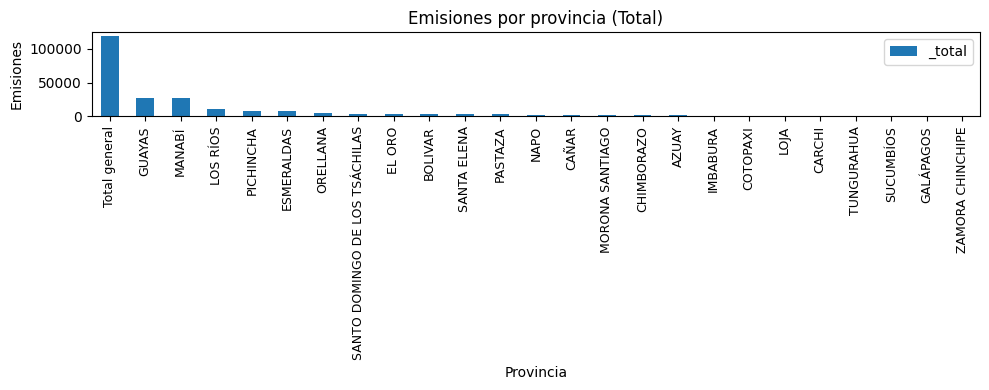

KPI (a) — Top 15 provincia×clase por Lift ponderado (prioridad operativa):


,unidad,clase,lift,lift_pond
0,Total general,a,1.00,118000.000000
1,Total general,a1,1.00,118000.000000
2,Total general,b,1.00,118000.000000
3,Total general,c,1.00,118000.000000
4,Total general,c1,1.00,118000.000000
5,Total general,d,1.00,118000.000000
6,Total general,e,1.00,118000.000000
7,Total general,f,1.00,118000.000000
8,Total general,g,1.00,118000.000000
9,MANABÍ,a1,3.44,91303.167421


Archivo export/kpi_lift_provincia_clase.csv generado exitosamente.


In [6]:
from textwrap import wrap

assert 'df_prov2' in globals() and 'prov_long' in globals(), "Ejecuta la Fase 3 primero."

def wrap_labels(ax, width=12):
    labs = [ "\n".join(wrap(str(t.get_text()), width)) for t in ax.get_xticklabels() ]
    ax.set_xticklabels(labs)

fig, ax = plt.subplots(figsize=(10,4))
(df_prov2.sort_values("_total", ascending=False)
 .plot(x="unidad", y="_total", kind="bar", ax=ax, title="Emisiones por provincia (Total)"))
ax.set_xlabel("Provincia"); ax.set_ylabel("Emisiones")
ax.tick_params(axis='x', labelrotation=90, labelsize=9)
plt.tight_layout()
plt.show()

# Heatmap
pivot_abs = (prov_long.pivot_table(index="unidad", columns="clase", values="emisiones", aggfunc="sum", fill_value=0).reindex(df_prov2["unidad"]))
fila_suma  = pivot_abs.sum(axis=1).replace(0, np.nan)
pivot_prop = (pivot_abs.div(fila_suma, axis=0)).fillna(0)

# KPI Lift ponderado
prop_pais = (pivot_abs.sum(axis=0) / pivot_abs.values.sum())
lift = pivot_prop.div(prop_pais, axis=1).replace([np.inf,-np.inf], np.nan).fillna(0.0)
op_score = (lift * df_prov2.set_index("unidad")["_total"].reindex(lift.index).values.reshape(-1,1))

top_lift = (op_score.stack().reset_index().rename(columns={"level_0":"unidad","level_1":"clase",0:"lift_pond"}).sort_values("lift_pond", ascending=False))

aux_prop_prov = pivot_prop.stack().rename("prop_prov").reset_index()
aux_prop_pais = prop_pais.rename("prop_pais").reset_index().rename(columns={"index":"clase"})
top15 = (top_lift.head(15).merge(aux_prop_prov, on=["unidad","clase"]).merge(aux_prop_pais, on="clase"))
top15["lift"]  = (top15["prop_prov"]/top15["prop_pais"]).round(2)

print("KPI (a) — Top 15 provincia×clase por Lift ponderado (prioridad operativa):")
display(top15[["unidad","clase","lift","lift_pond"]].head(10))

# Exportables
Path("export").mkdir(exist_ok=True)
top15.to_csv("export/kpi_lift_provincia_clase.csv", index=False)
print("Archivo export/kpi_lift_provincia_clase.csv generado exitosamente.")
